/tmp/ipykernel_81044/2306708170.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_advers['model_name'] = pd.Categorical(df_advers['model_name'], categories=model_order, ordered=True)
/tmp/ipykernel_81044/2306708170.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orig['model_name'] = pd.Categorical(df_orig['model_name'], categories=model_order, ordered=True)
/tmp/ipykernel_81044/2306708170.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

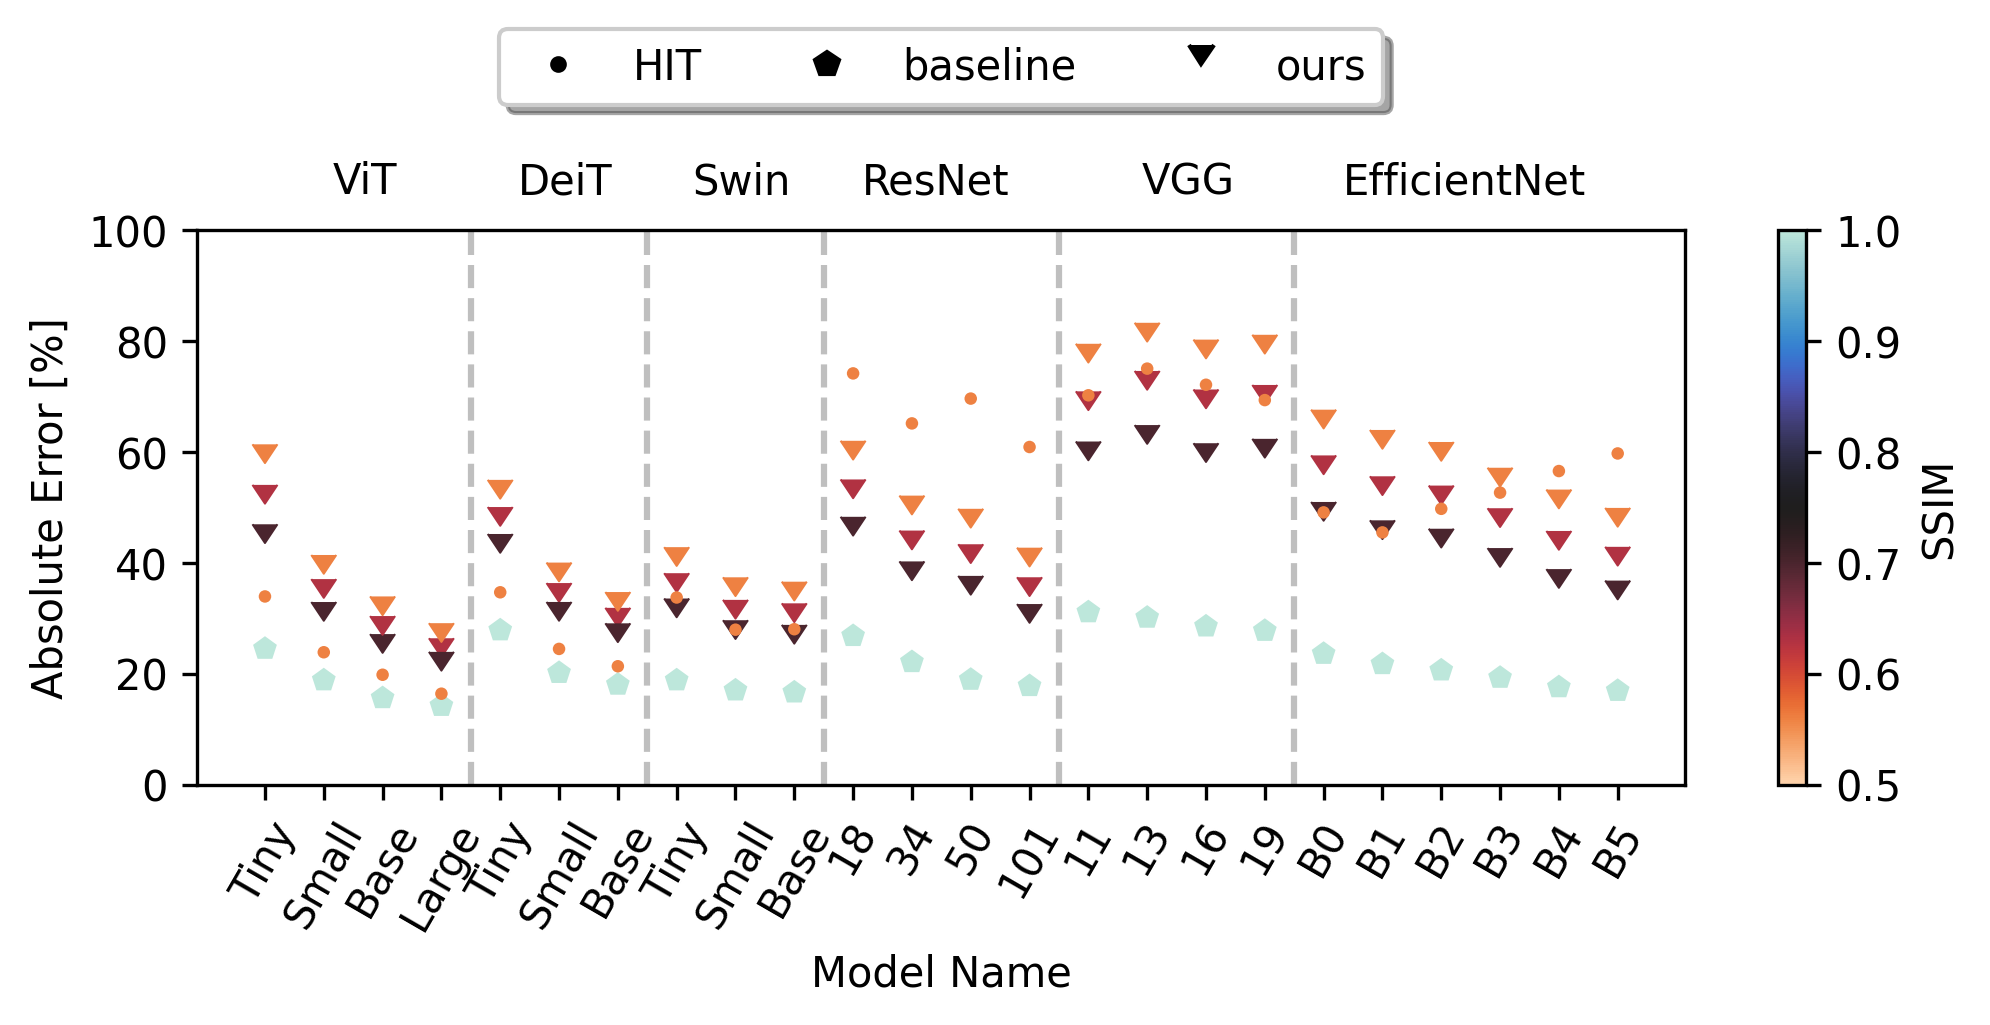

In [ ]:
# Legacy, better is in cell below
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import dataclasses
import enum

plt.rcParams["patch.force_edgecolor"] = False

class Attack(enum.Enum):
    BASELINE = "baseline"
    AGS = "AGS"
    BIA = "BIA"
    HIT = "HIT"
    RINA = "RINA"
    PRIMITIVE_BLUR = "blur"

@dataclasses.dataclass
class DataFile:
    alpha: float
    filename: str
    attack: Attack
    ssim: float

files = [
    DataFile(alpha=0.85, filename="eval_adversarial-0.85_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.7),
    DataFile(alpha=1.0, filename="eval_adversarial-1.0_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.63),
    DataFile(alpha=1.15, filename="eval_adversarial-1.15_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.56),
    # DataFile(alpha=1.3, filename="eval_adversarial-1.3_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.5),
    # DataFile(alpha=1.2, filename="eval_adversarial-1.2_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.574),
    # DataFile(alpha=1.225, filename="eval_adversarial-1.225_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.530),
    # DataFile(alpha=1.25, filename="eval_adversarial-1.25_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.52),
    # DataFile(alpha=1.275, filename="eval_adversarial-1.275_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.500),

    # DataFile(alpha=1.3, filename="eval_adversarial-1.3_tag-existing-bei.csv", attack=Attack.BIA, ssim=0.56),
    # DataFile(alpha=0.75, filename="eval_adversarial-0.75_tag-existing-ags.csv", attack=Attack.AGS), ssim=0.56,
    DataFile(alpha=1.0, filename="eval_adversarial-x.x_tag-HIT.csv", attack=Attack.HIT, ssim=0.56001),
    DataFile(alpha=0.0, filename="eval_emuzc_resnet50_fmqt-mobilenetv3/eval_adversarial-0.0_tag-emuzc.csv", attack=Attack.BASELINE, ssim=1.0),
    DataFile(alpha=1.0, filename="val_primitive/blur.csv", attack=Attack.PRIMITIVE_BLUR, ssim=0.57),
]

dfs = []
for f in files:
    df = pd.read_csv(f.filename)
    df["attack"] = f.attack.value
    df["alpha"] = f.alpha
    df["ssim"] = f.ssim
    df["model_name"] = df["model"].apply(lambda x: x.split(".")[0])
    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df = df[df["model"] != "vit_base_patch16_224.augreg2_in21k_ft_in1k"]




sortby = ["model_name"] # used in the paper
# palette = sns.color_palette("ch:", as_cmap=True).reversed() # Reversed the color palette
palette = sns.color_palette("icefire", as_cmap=True).reversed() # Reversed the color palette
fig, axis = plt.subplots(1, 1, figsize=(8,  2.4), dpi=300)
axis = [axis,]

df = df.sort_values(by=sortby)

handles = [
    matplotlib.lines.Line2D([], [], marker=".",  linewidth=0, color="black"),
    matplotlib.lines.Line2D([], [], marker="p",  linewidth=0, color="black"),
    matplotlib.lines.Line2D([], [], marker=7,  linewidth=0, color="black"),
]
labels = [
    # r"$$\mathbf{D}_{\text{HIT}}$$",
    # r"$$\mathbf{D}_{o}$$",
    "HIT",
    "baseline",
    "ours",
]

axis[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.4),
        fancybox=True, shadow=True, ncol=14, handles=handles, labels=labels)

df_orig = df[df["attack"] == str(Attack.BASELINE.value)]
df_kokos = df[df["attack"] == str(Attack.HIT.value)]
df_advers = df[df["attack"] == str(Attack.RINA.value)]

# Sort the dataframes by model name in desired order
model_order = [
    'vit_tiny_patch16_224', 'vit_small_patch16_224', 'vit_base_patch16_224', 'vit_large_patch16_224',
    'deit_tiny_patch16_224', 'deit_small_patch16_224', 'deit_base_patch16_224',
    'swin_tiny_patch4_window7_224', 'swin_small_patch4_window7_224', 'swin_base_patch4_window7_224',
    'resnet18', 'resnet34', 'resnet50', 'resnet101',
    'vgg11', 'vgg13', 'vgg16', 'vgg19',
    'tf_efficientnet_b0', 'tf_efficientnet_b1', 'tf_efficientnet_b2', 
    'tf_efficientnet_b3', 'tf_efficientnet_b4', 'tf_efficientnet_b5'
]

df_advers['model_name'] = pd.Categorical(df_advers['model_name'], categories=model_order, ordered=True)
df_orig['model_name'] = pd.Categorical(df_orig['model_name'], categories=model_order, ordered=True)
df_kokos['model_name'] = pd.Categorical(df_kokos['model_name'], categories=model_order, ordered=True)

# # Add vertical lines to separate model families
# model_family_boundaries = [4, 7, 10, 14, 18]  # Indices where each family ends

# # Add text labels for model families
# model_family_labels = ['ViT', 'DeiT', 'Swin', 'ResNet', 'VGG', 'EfficientNet']
# label_positions = [-0.5] + [idx-0.5 for idx in model_family_boundaries]
# for label, pos in zip(model_family_labels, label_positions):
#     plt.text(pos + 2, 1.05, label, ha='center', va='bottom', transform=axis[0].get_xaxis_transform())

# # Add vertical lines to separate model families
model_family_boundaries = [4, 7, 10, 14, 18, 24]  # Indices where each family ends
# Add text labels for model families
model_family_labels = ['ViT', 'DeiT', 'Swin', 'ResNet', 'VGG', 'EfficientNet']
# Calculate centers and adjust based on text length
# ViT (3 chars): models 0-3 (4 models) -> center at 2
# DeiT (4 chars): models 4-6 (3 models) -> center at 5.5
# Swin (4 chars): models 7-9 (3 models) -> center at 8.5
# ResNet (6 chars): models 10-13 (4 models) -> center at 12
# VGG (3 chars): models 14-17 (4 models) -> center at 16
# EfficientNet (11 chars): models 18-23 (6 models) -> center at 21
text_offsets = [len(label) * 0.1 for label in model_family_labels]  # Shift left proportional to text length
text_offsets[5] = text_offsets[5] * 0.5  # Reduce offset for EfficientNet
family_centers = [2, 5.5, 8.5, 12, 16, 21]
for label, pos, offset in zip(model_family_labels, family_centers, text_offsets):
    plt.text(pos - offset, 1.05, label, ha='center', va='bottom', transform=axis[0].get_xaxis_transform())
sns.scatterplot(
    edgecolor='none',
    ax=axis[0], 
    data=df_advers,
    x="model_name",
    y="top1_err",
    hue='ssim',
    palette=palette,
    marker=7,
    hue_norm=(0.5, 1.0)  # Set hue range from 0.5 to 1.0
)
sns.scatterplot(
    edgecolor='none',
    ax=axis[0], 
    data=df_orig,
    x="model_name",
    y="top1_err",
    hue='ssim',
    palette=palette,
    marker="p",
    hue_norm=(0.5, 1.0)  # Set hue range from 0.5 to 1.0
)
sns.scatterplot(
    edgecolor='none',
    ax=axis[0], 
    data=df_kokos,
    x="model_name",
    y="top1_err",
    hue='ssim',
    palette=palette,
    marker=".",
    hue_norm=(0.5, 1.0)  # Set hue range from 0.5 to 1.0
)
# sns.scatterplot(
#     edgecolor='none',
#     ax=axis[0], 
#     data=df_advers,
#     x="model_name",
#     y="top1_err",
#     hue='ssim',
#     palette=palette,
#     marker=7,
#     hue_norm=(0.5, 1.0)  # Set hue range from 0.5 to 1.0
# )
# sns.scatterplot(
#     edgecolor='none',
#     ax=axis[0],
#     data=df_orig,
#     x="model_name", 
#     y="top1_err",
#     color=palette(1.0), # psnr_and_ssim similarity score is constant for all kokosaci models
#     marker="p",
# )
# sns.scatterplot(
#     ax=axis[0],
#     data=df_kokos,
#     x="model_name",
#     y="top1_err", 
#     color=palette(0.56), # psnr_and_ssim similarity score is constant for all kokosaci models
#     marker=".",
#     edgecolor='none'
# )

# Add vertical lines after plotting points
for idx in model_family_boundaries[:-1]: # do not show last line
    axis[0].axvline(x=idx-0.5, color='gray', linestyle='--', alpha=0.5)

axis[0].set_ylabel("Absolute Error [%]")
axis[0].set_xlabel("Model Name")
axis[0].set_ylim(0,100)
axis[0].tick_params(axis="x", rotation=60)
# Create mapping of model names to shorter names
name_mapping = {
    'deit_base_patch16_224': 'Base',
    'deit_small_patch16_224': 'Small', 
    'deit_tiny_patch16_224': 'Tiny',
    'resnet101': '101',
    'resnet18': '18',
    'resnet34': '34', 
    'resnet50': '50',
    'swin_base_patch4_window7_224': 'Base',
    'swin_small_patch4_window7_224': 'Small',
    'swin_tiny_patch4_window7_224': 'Tiny',
    'tf_efficientnet_b0': 'B0',
    'tf_efficientnet_b1': 'B1',
    'tf_efficientnet_b2': 'B2',
    'tf_efficientnet_b3': 'B3',
    'tf_efficientnet_b4': 'B4',
    'tf_efficientnet_b5': 'B5',
    'vgg11': '11',
    'vgg13': '13',
    'vgg16': '16',
    'vgg19': '19',
    'vit_base_patch16_224': 'Base',
    'vit_large_patch16_224': 'Large',
    'vit_small_patch16_224': 'Small',
    'vit_tiny_patch16_224': 'Tiny'
}

# Get current tick labels
ticks = axis[0].get_xticklabels()
# Replace with shorter names
axis[0].set_xticklabels([name_mapping[t.get_text()] for t in ticks])


# Create continuous colorbar
# cmap = sns.color_palette('ch:', as_cmap=True)
cmap = palette
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0.5, vmax=1.0))  # Set colorbar range from 0.5 to 1.0
cbar = fig.colorbar(sm, ax=axis)
cbar.set_label('SSIM')

axis[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.4),
        fancybox=True, shadow=True, ncol=14, handles=handles, labels=labels)


plt.show()
# df = df.sort_values(by=sortby)

# plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker (7).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)
/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)
/tmp/ipykernel_81044/638352300.py:262: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([tick_map[str(t.get_text())] for t in ax.get_xticklabels()])


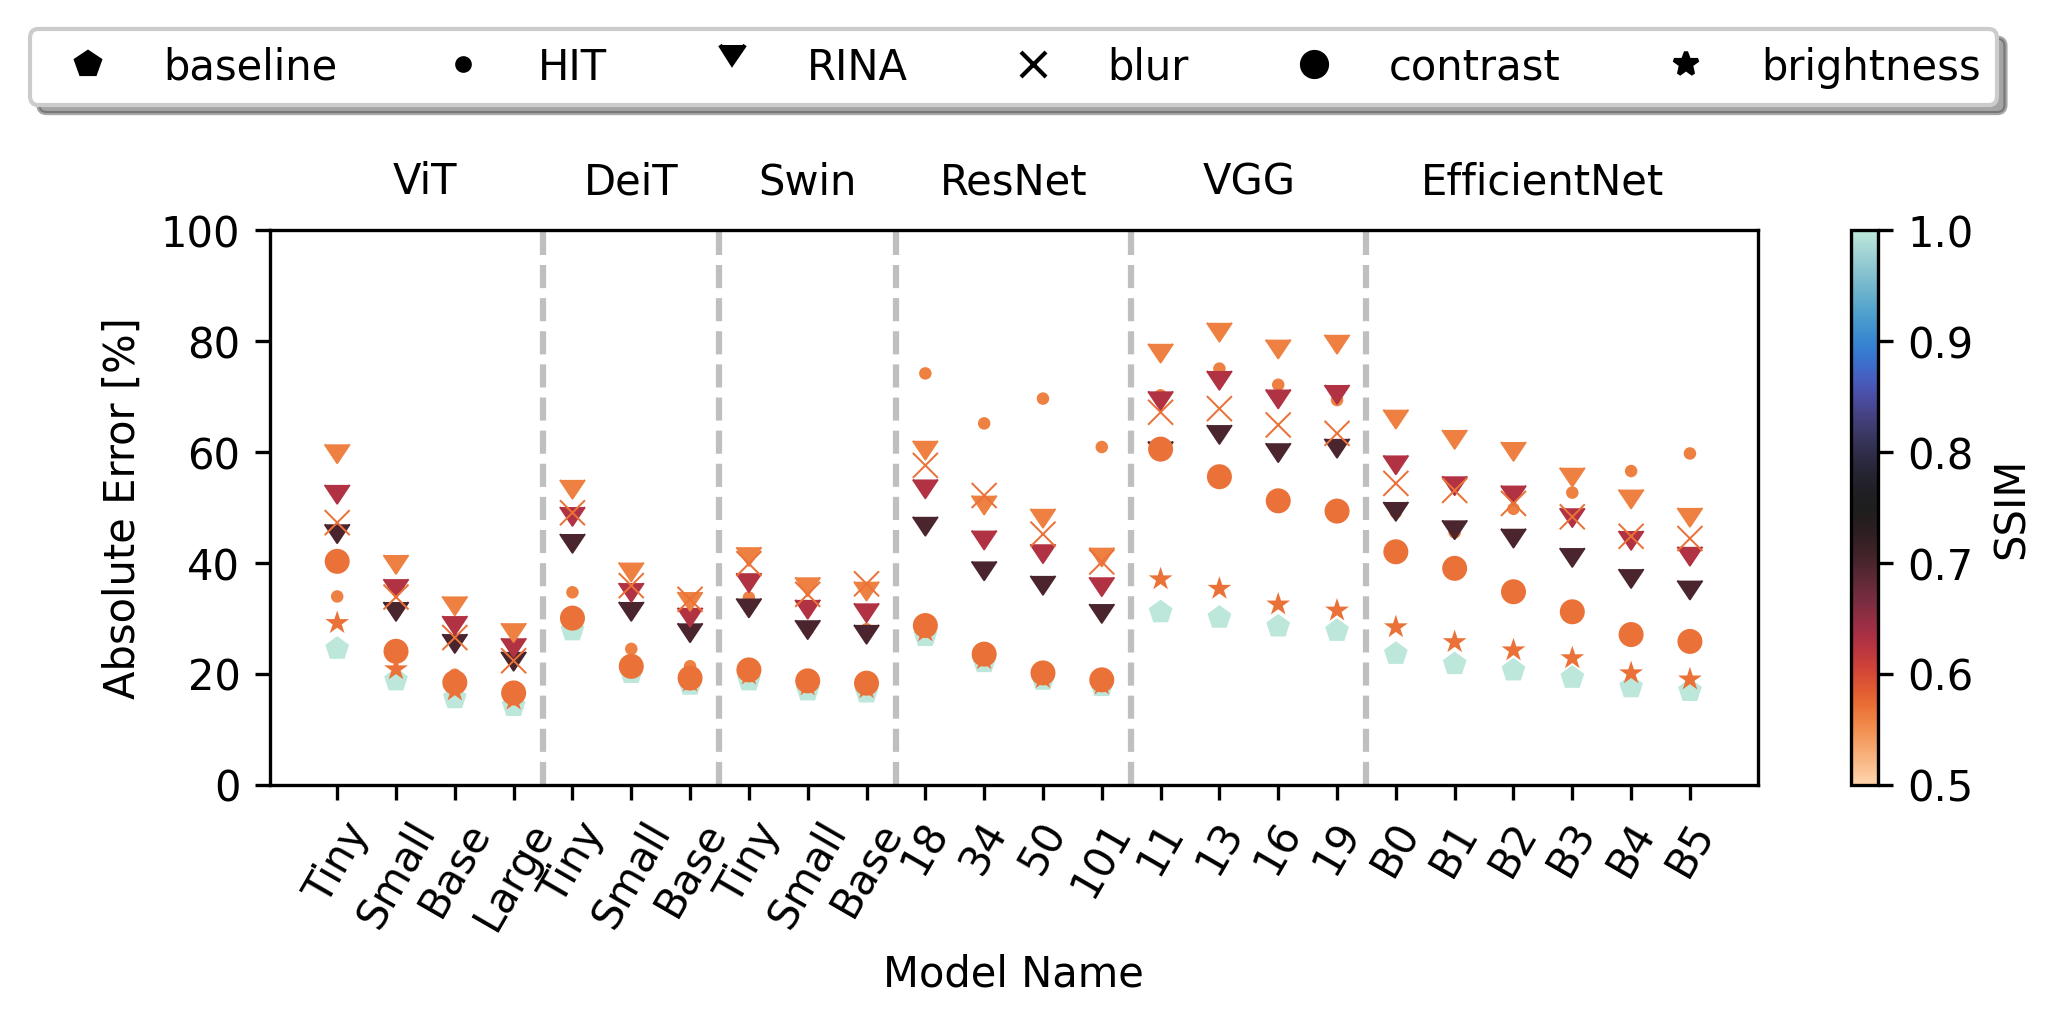

In [ ]:
# Rewritten version below

import re
import enum
import dataclasses
from typing import Dict, List, Tuple
import dataclasses


import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["patch.force_edgecolor"] = False


# -----------------------------
# 1) Inputs (only edit this list)
# -----------------------------
class Attack(enum.Enum):
    BASELINE = "baseline"
    AGS = "AGS"
    BIA = "BIA"
    HIT = "HIT"
    RINA = "RINA"
    PRIMITIVE_BLUR = "blur"
    PRIMITIVE_CONTRAST = "contrast"
    PRIMITIVE_BRIGHTNESS = "brightness"

@dataclasses.dataclass
class PlotConfig:
    marker: str
    label: str
    attack_key: Attack



@dataclasses.dataclass(frozen=True)
class DataFile:
    alpha: float
    filename: str
    attack: Attack
    ssim: float
    plot_config: PlotConfig = None


files = [
    DataFile(alpha=0.85, filename="eval_adversarial-0.85_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.70, plot_config=PlotConfig(marker=7, label="ours", attack_key=Attack.RINA)),
    DataFile(alpha=1.00, filename="eval_adversarial-1.0_tag-emuzc-reflect.csv",  attack=Attack.RINA, ssim=0.63, plot_config=PlotConfig(marker=7, label="ours", attack_key=Attack.RINA)),
    DataFile(alpha=1.15, filename="eval_adversarial-1.15_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.56, plot_config=PlotConfig(marker=7, label="ours", attack_key=Attack.RINA)),

    DataFile(alpha=1.00, filename="eval_adversarial-x.x_tag-HIT.csv", attack=Attack.HIT, ssim=0.56001, plot_config=PlotConfig(marker=".", label="HIT", attack_key=Attack.HIT)),
    DataFile(alpha=0.00, filename="eval_emuzc_resnet50_fmqt-mobilenetv3/eval_adversarial-0.0_tag-emuzc.csv",
             attack=Attack.BASELINE, ssim=1.0, plot_config=PlotConfig(marker="p", label="baseline", attack_key=Attack.BASELINE)),
    DataFile(alpha=1.00, filename="val_primitive/blur.csv", attack=Attack.PRIMITIVE_BLUR, ssim=0.57, plot_config=PlotConfig(marker="x", label="blur", attack_key=Attack.PRIMITIVE_BLUR)),
    DataFile(alpha=1.00, filename="val_primitive/contrast.csv", attack=Attack.PRIMITIVE_CONTRAST, ssim=0.57, plot_config=PlotConfig(marker="o", label="contrast", attack_key=Attack.PRIMITIVE_CONTRAST)),
    DataFile(alpha=1.00, filename="val_primitive/brightness.csv", attack=Attack.PRIMITIVE_BRIGHTNESS, ssim=0.57, plot_config=PlotConfig(marker="*", label="brightness", attack_key=Attack.PRIMITIVE_BRIGHTNESS)),
]


# -----------------------------
# 2) Loading + normalization
# -----------------------------
def _model_stem(model: str) -> str:
    # "vit_tiny_patch16_224.augreg2_in21k_ft_in1k" -> "vit_tiny_patch16_224"
    return str(model).split(".")[0]


def load_eval(files: List[DataFile]) -> pd.DataFrame:
    dfs = []
    for f in files:
        d = pd.read_csv(f.filename)
        d["attack"] = f.attack.value
        d["alpha"] = f.alpha
        d["ssim"] = float(f.ssim)
        d["model_name"] = d["model"].map(_model_stem)
        d["plot_marker"] = f.plot_config.marker
        d["plot_label"] = f.plot_config.label
        d["plot_attack_key"] = f.plot_config.attack_key.value
        dfs.append(d)
    if not dfs:
        raise ValueError("No input files.")
    df = pd.concat(dfs, ignore_index=True)

    # Optional: filter out known duplicates if present
    df = df[df["model"] != "vit_base_patch16_224.augreg2_in21k_ft_in1k"].copy()

    # Basic sanity checks for expected columns
    required = {"model", "model_name", "top1_err", "attack", "ssim"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in input CSV(s): {sorted(missing)}")

    return df


# -----------------------------
# 3) Automatic model ordering + labels + family boundaries
# -----------------------------
_FAMILY_ORDER = ["ViT", "DeiT", "Swin", "ResNet", "VGG", "EfficientNet", "Other"]


def _family_of(model_name: str) -> str:
    m = model_name
    if m.startswith("vit_"):
        return "ViT"
    if m.startswith("deit_"):
        return "DeiT"
    if m.startswith("swin_"):
        return "Swin"
    if m.startswith("resnet"):
        return "ResNet"
    if m.startswith("vgg"):
        return "VGG"
    if "efficientnet" in m:
        return "EfficientNet"
    return "Other"


def _within_family_key(model_name: str) -> Tuple:
    fam = _family_of(model_name)

    if fam in {"ViT", "DeiT", "Swin"}:
        # Prefer Tiny < Small < Base < Large if present
        order = {"tiny": 0, "small": 1, "base": 2, "large": 3}
        m = re.search(r"_(tiny|small|base|large)_", model_name)
        return (order.get(m.group(1), 99) if m else 99, model_name)

    if fam == "ResNet":
        m = re.search(r"resnet(\d+)", model_name)
        return (int(m.group(1)) if m else 10**9, model_name)

    if fam == "VGG":
        m = re.search(r"vgg(\d+)", model_name)
        return (int(m.group(1)) if m else 10**9, model_name)

    if fam == "EfficientNet":
        # tf_efficientnet_b0 ... -> B0 < B1 < ...
        m = re.search(r"_b(\d+)", model_name)
        return (int(m.group(1)) if m else 10**9, model_name)

    return (10**9, model_name)


def build_model_axis(df: pd.DataFrame) -> Tuple[List[str], Dict[str, str], List[int], List[str], List[float]]:
    models = sorted(df["model_name"].unique(), key=lambda m: (_FAMILY_ORDER.index(_family_of(m)),) + _within_family_key(m))

    # Short tick labels
    tick_map: Dict[str, str] = {}
    for m in models:
        fam = _family_of(m)
        if fam in {"ViT", "DeiT", "Swin"}:
            mm = re.search(r"_(tiny|small|base|large)_", m)
            tick_map[m] = mm.group(1).capitalize() if mm else m
        elif fam == "ResNet":
            mm = re.search(r"resnet(\d+)", m)
            tick_map[m] = mm.group(1) if mm else m
        elif fam == "VGG":
            mm = re.search(r"vgg(\d+)", m)
            tick_map[m] = mm.group(1) if mm else m
        elif fam == "EfficientNet":
            mm = re.search(r"_b(\d+)", m)
            tick_map[m] = f"B{mm.group(1)}" if mm else m
        else:
            tick_map[m] = m

    # Family boundaries (vertical separators) + label positions
    families = [_family_of(m) for m in models]
    boundaries = []
    family_labels = []
    family_centers = []

    start = 0
    for i in range(1, len(models) + 1):
        if i == len(models) or families[i] != families[start]:
            fam = families[start]
            end = i  # exclusive
            if fam != "Other":
                family_labels.append(fam)
                family_centers.append((start + end - 1) / 2.0)
            boundaries.append(end)  # boundary after this block
            start = i

    # separators at boundaries between families (exclude last)
    separators = [b for b in boundaries[:-1] if b > 0]

    return models, tick_map, separators, family_labels, family_centers


# -----------------------------
# 4) Plot (auto adapts to whatever files you add)
# -----------------------------
def plot_figure(df: pd.DataFrame, figsize=(8, 2.4), dpi=300):

    # Build x-axis categorical ordering
    models, tick_map, separators, fam_labels, fam_centers = build_model_axis(df)
    df = df.copy()
    df["model_name"] = pd.Categorical(df["model_name"], categories=models, ordered=True)

    # Color mapping by SSIM (continuous)
    palette = sns.color_palette("icefire", as_cmap=True).reversed()

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

    handles, labels = [], []
    for attack in Attack:
        df_attack = df[df["attack"] == attack.value]
        if len(df_attack) == 0:
            continue
        marker = df_attack["plot_marker"].iloc[0]
        label = df_attack["plot_label"].iloc[0]
        sns.scatterplot(
            ax=ax, data=df_attack, x="model_name", y="top1_err",
            hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
            marker=marker, edgecolor="none"
        )
        # Custom marker legend (HIT/baseline/ours)
        handles.append(
            matplotlib.lines.Line2D([], [], marker=marker, linestyle="None", color="black"),
        )
        labels.append(attack.value)


    # Draw in a stable order (others behind, then baseline, then HIT)
    # if len(df_baseline):
    #     sns.scatterplot(
    #         ax=ax, data=df_baseline, x="model_name", y="top1_err",
    #         hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
    #         marker="p", edgecolor="none"
    #     )
    # if len(df_hit):
    #     sns.scatterplot(
    #         ax=ax, data=df_hit, x="model_name", y="top1_err",
    #         hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
    #         marker=".", edgecolor="none"
    #     )
    # if len(df_blur):
    #     sns.scatterplot(
    #         ax=ax, data=df_blur, x="model_name", y="top1_err",
    #         hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
    #         marker="X", edgecolor="none"
    #     )

    # Remove seaborn's automatic legend (we add a custom one + colorbar)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Vertical separators between families
    for idx in separators:
        ax.axvline(x=idx - 0.5, color="gray", linestyle="--", alpha=0.5)

    # Family labels on top
    for fam, center in zip(fam_labels, fam_centers):
        ax.text(center, 1.05, fam, ha="center", va="bottom", transform=ax.get_xaxis_transform())

    # Axis labels/limits
    ax.set_ylabel("Absolute Error [%]")
    ax.set_xlabel("Model Name")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=60)

    # Short tick labels
    ax.set_xticklabels([tick_map[str(t.get_text())] for t in ax.get_xticklabels()])

    # Colorbar for SSIM
    sm = plt.cm.ScalarMappable(cmap=palette, norm=plt.Normalize(vmin=0.5, vmax=1.0))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("SSIM")
    ax.legend(
        loc="upper center", bbox_to_anchor=(0.5, 1.4),
        fancybox=True, shadow=True, ncol=14,
        handles=handles, labels=labels
    )

    plt.show()


df = load_eval(files)
plot_figure(df)


In [ ]:
df_attack


NameError: name 'df_attack' is not defined

TypeError: seaborn.utils._scatter_legend_artist() got multiple values for keyword argument 'label'

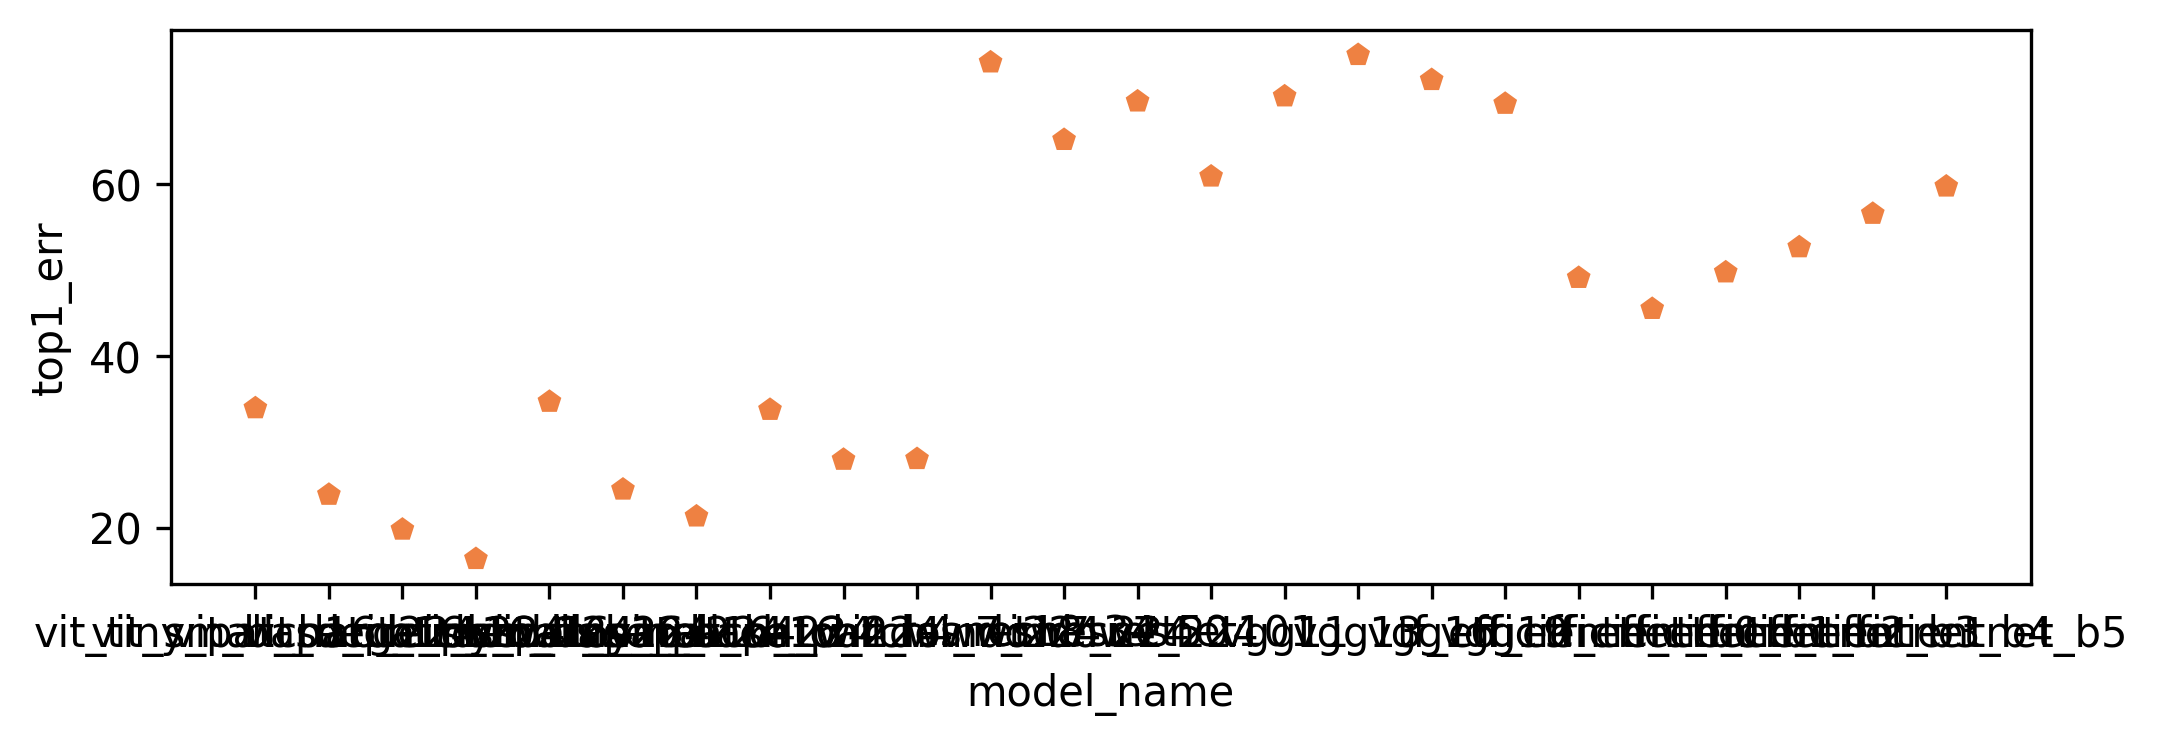

In [4]:
baseline = df.groupby(["attack", "alpha"]).mean().loc[("baseline",)]["top1_err"]
(df.groupby(["attack", "alpha"]).mean()["top1_err"] - baseline[0]).round()
print(baseline)

alpha
0.0    21.462417
Name: top1_err, dtype: float64


/tmp/ipykernel_305267/2656329382.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  baseline = df.groupby(["attack", "alpha"]).mean().loc[("baseline",)]["top1_err"]
/tmp/ipykernel_305267/2656329382.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  (df.groupby(["attack", "alpha"]).mean()["top1_err"] - baseline[0]).round()


In [12]:
df['architecture'] = df['model'].str.lower().apply(
    lambda x: 'transformer' if any(t in x for t in ['vit', 'swin', 'deit']) else 'cnn'
)
df_t = df[df["architecture"] == "transformer"]
baseline_t = df_t.groupby(["attack", "alpha"]).mean().loc[("baseline",)]["top1_err"]
diff_t = (df_t.groupby(["attack", "alpha"]).mean()["top1_err"] - baseline_t[0]).round()
# print(df_t.groupby(["attack", "alpha"]).mean())
print(diff_t)

attack    alpha
HIT       1.00      7.0
RINA      0.85     10.0
          1.00     14.0
          1.15     19.0
baseline  0.00      0.0
Name: top1_err, dtype: float64


/tmp/ipykernel_305267/176414100.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  baseline_t = df_t.groupby(["attack", "alpha"]).mean().loc[("baseline",)]["top1_err"]
/tmp/ipykernel_305267/176414100.py:6: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  diff_t = (df_t.groupby(["attack", "alpha"]).mean()["top1_err"] - baseline_t[0]).round()


In [20]:
print(sorted(list(df_t[df_t["alpha"] == 1.15]["top1_err"])))

[25.76, 30.584, 31.376, 33.242, 34.032, 36.688, 38.058, 39.472, 51.606, 58.02]


In [41]:

df_c = df[df["architecture"] == "cnn"]
baseline_c = df_c.groupby(["attack", "alpha"]).mean().loc[("baseline",)]["top1_err"]
(df_c.groupby(["attack", "alpha"]).mean()["top1_err"] - baseline_c[0]).round()

/tmp/ipykernel_4182489/1695556483.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  baseline_c = df_c.groupby(["attack", "alpha"]).mean().loc[("baseline",)]["top1_err"]
/tmp/ipykernel_4182489/1695556483.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  (df_c.groupby(["attack", "alpha"]).mean()["top1_err"] - baseline_c[0]).round()


attack    alpha
HIT       1.00     39.0
RINA      0.85     22.0
          1.00     29.0
          1.15     37.0
baseline  0.00      0.0
Name: top1_err, dtype: float64

In [26]:
baseline[0]

21.462416666666666

In [23]:
df.groupby(["attack", "alpha"]).mean()["top1_err"]

/tmp/ipykernel_4182489/2293818362.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby(["attack", "alpha"]).mean()["top1_err"]


attack    alpha
HIT       1.00     47.278904
RINA      0.85     38.426667
          1.00     44.487667
          1.15     50.679750
baseline  0.00     21.462417
Name: top1_err, dtype: float64

In [35]:
df[df["alpha"] == 1.3]

,model,top1,top1_err,top5,top5_err,param_count,img_size,crop_pct,interpolation,attack,alpha,ssim,model_name
78,deit_base_patch16_224.fb_in1k,1.3501,98.6499,1.5071,98.4929,86.57,224,0.900,bicubic,RINA,1.3,0.5,deit_base_patch16_224
80,deit_small_patch16_224.fb_in1k,1.2873,98.7127,1.4443,98.5557,22.05,224,0.900,bicubic,RINA,1.3,0.5,deit_small_patch16_224
87,deit_tiny_patch16_224.fb_in1k,1.0989,98.9011,1.2873,98.7127,5.72,224,0.900,bicubic,RINA,1.3,0.5,deit_tiny_patch16_224
88,resnet101.a1_in1k,1.0989,98.9011,1.3501,98.6499,44.55,288,1.000,bicubic,RINA,1.3,0.5,resnet101
90,resnet18.a1_in1k,0.9419,99.0581,1.3187,98.6813,11.69,288,1.000,bicubic,RINA,1.3,0.5,resnet18
89,resnet34.a1_in1k,0.9733,99.0267,1.4129,98.5871,21.80,288,1.000,bicubic,RINA,1.3,0.5,resnet34
91,resnet50.a1_in1k,0.8791,99.1209,1.1303,98.8697,25.56,288,1.000,bicubic,RINA,1.3,0.5,resnet50
81,swin_base_patch4_window7_224.ms_in1k,1.2873,98.7127,1.4757,98.5243,87.77,224,0.900,bicubic,RINA,1.3,0.5,swin_base_patch4_window7_224
82,swin_small_patch4_window7_224.ms_in1k,1.2873,98.7127,1.4757,98.5243,49.61,224,0.900,bicubic,RINA,1.3,0.5,swin_small_patch4_window7_224
83,swin_tiny_patch4_window7_224.ms_in1k,1.2559,98.7441,1.4129,98.5871,28.29,224,0.900,bicubic,RINA,1.3,0.5,swin_tiny_patch4_window7_224


In [69]:
import glob
import cv2
import numpy as np

datasets = [f"/datasets/imagenet/rescale-invariant-nobox-attack/_adversarial-{x}_tag-emuzc-reflect" for x in ["0.85", "1.0", "1.15"]]
datasets += ["/datasets/imagenet/val"]
n_images = 3


for n in range(n_images):
    im_paths = []
    for d in datasets:
        im_paths.append(sorted(glob.glob(f"{d}/**/*"))[n])
    images = []
    for p in im_paths:
        images.append(cv2.cvtColor(cv2.imread(p),cv2.COLOR_BGR2RGB).astype(np.float32))
    diff = (images[1] - images[-1])
    cv2.imwrite(f"diff_{n}.png", diff)
    
    # print(diff.max())
    # # Show all 4 images (3 adversarial + 1 clean)
    # import matplotlib.pyplot as plt

    # fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    # for i, (img, path) in enumerate(zip(images, im_paths)):
    #     axes[i].imshow(img.astype(np.uint8))
    #     axes[i].set_title(f"{path.split('/')[-3]}")
    #     axes[i].axis('off')
    # plt.tight_layout()
    # plt.show()
    # plt.imshow(diff, cmap='gray')
    # plt.axis('off')
    # plt.gca().spines['top'].set_visible(False)
    # plt.gca().spines['right'].set_visible(False)
    # plt.gca().spines['left'].set_visible(False)
    # plt.gca().spines['bottom'].set_visible(False)
    # plt.show()
    # raise
    
raise



image_sets = []
for d in datasets:
    im_set = []
    for i in range(n):
        im_set.append(sorted(glob.glob(f"{d}/**/*"))[i])
    image_sets.append(im_set)

print(image_sets[0])
raise

for im_p in image_sets:
    lower, normal, higher =[cv2.imread(x) for x in im_p]




RuntimeError: No active exception to reraise